<a href="https://colab.research.google.com/github/riballes/mobile-rag-firewall-/blob/main/experiments/phi_ner/notebooks/04_ablation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PHI NER — Ablation Study

An ablation study isolates which design choices actually matter by changing one variable at a time and measuring the impact.

**What it does:**
1. **Data ablations** — What happens if we remove synthetic examples? Remove negatives? Train on names only?
2. **Training ablations** — How sensitive is F1 to epochs, learning rate, batch size?
3. **Class imbalance** — Does oversampling entity-rich examples help? (99.2% of tokens are "O")

All experiments use DistilBERT as the base model (fastest, best F1 from notebook 01). Each experiment is a separate W&B run tagged with "ablation" for easy filtering on the dashboard.

**Runtime**: GPU (T4)

**Estimated time**: ~1-1.5 hours (15+ training runs, batch size 32)

In [1]:
!pip install -q transformers torch wandb weave seqeval accelerate matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.5/983.5 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.9/52.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 93.4 MB/s eta 0:00:00


In [2]:
import wandb, weave, json, copy, numpy as np, matplotlib.pyplot as plt, torch
from pathlib import Path
from torch.utils.data import Dataset as TorchDataset
from transformers import (AutoModelForTokenClassification, AutoTokenizer, Trainer,
                          TrainingArguments, DataCollatorForTokenClassification)
from seqeval.metrics import f1_score
from seqeval.scheme import IOB2
from google.colab import userdata

try: wandb.login(key=userdata.get("WANDB_API_KEY"))
except: wandb.login()
weave.init("mobile-rag-firewall")
print(f"GPU: {torch.cuda.is_available()}")

LABEL_LIST = ["O", "B-NAME", "I-NAME", "B-ADDRESS", "I-ADDRESS"]
LABEL_TO_ID = {l: i for i, l in enumerate(LABEL_LIST)}
ID_TO_LABEL = {i: l for l, i in LABEL_TO_ID.items()}

train_data = weave.ref("phi-ner-train:latest").get().rows
val_data = weave.ref("phi-ner-val:latest").get().rows
test_data = weave.ref("phi-ner-test:latest").get().rows
print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ricardo-morales-b to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave


GPU: True
Train: 8682, Val: 1861, Test: 1861


In [3]:
class PHINERDataset(TorchDataset):
    def __init__(self, data, tokenizer, max_length=256):
        self.data, self.tokenizer, self.max_length = data, tokenizer, max_length
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        tokens, ner_tags = self.data[idx]["tokens"], self.data[idx]["ner_tags"]
        enc = self.tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=self.max_length, padding=False)
        labels, prev = [], None
        for wid in enc.word_ids():
            if wid is None: labels.append(-100)
            elif wid != prev:
                labels.append(LABEL_TO_ID.get(ner_tags[wid] if wid < len(ner_tags) else "O", 0))
            else:
                tag = ner_tags[wid] if wid < len(ner_tags) else "O"
                if tag.startswith("B-"): labels.append(LABEL_TO_ID.get("I-"+tag[2:], 0))
                elif tag.startswith("I-"): labels.append(LABEL_TO_ID.get(tag, 0))
                else: labels.append(-100)
            prev = wid
        enc["labels"] = labels
        return {k: torch.tensor(v) for k, v in enc.items()}

def compute_metrics(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=-1)
    true_seqs, pred_seqs = [], []
    for ps, ls in zip(preds, eval_pred.label_ids):
        t, p = [], []
        for pr, la in zip(ps, ls):
            if la != -100: t.append(ID_TO_LABEL[la]); p.append(ID_TO_LABEL[pr])
        true_seqs.append(t); pred_seqs.append(p)
    return {"f1_entity": f1_score(true_seqs, pred_seqs, mode='strict', scheme=IOB2)}

def run_ablation(name, train_d, val_d, test_d, model_name="distilbert-base-uncased",
                 lr=5e-5, epochs=5, batch_size=32, wd=0.01, tags=None):
    """Train one ablation, return test F1."""
    wandb.init(project="mobile-rag-firewall", name=f"abl-{name}",
               config={"ablation": name, "lr": lr, "epochs": epochs, "bs": batch_size},
               tags=["ablation"] + (tags or []), reinit=True)
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForTokenClassification.from_pretrained(model_name, num_labels=5, id2label=ID_TO_LABEL, label2id=LABEL_TO_ID)
    args = TrainingArguments(output_dir=f"abl_{name}", report_to="wandb", num_train_epochs=epochs,
        per_device_train_batch_size=batch_size, learning_rate=lr, weight_decay=wd,
        eval_strategy="epoch", save_strategy="no", logging_steps=100,
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=2, dataloader_pin_memory=True)
    trainer = Trainer(model=model, args=args, train_dataset=PHINERDataset(train_d, tok),
                      eval_dataset=PHINERDataset(val_d, tok),
                      data_collator=DataCollatorForTokenClassification(tok), compute_metrics=compute_metrics)
    trainer.train()
    test_res = trainer.predict(PHINERDataset(test_d, tok))
    preds = np.argmax(test_res.predictions, axis=-1)
    true_s, pred_s = [], []
    for ps, ls in zip(preds, test_res.label_ids):
        t, p = [], []
        for pr, la in zip(ps, ls):
            if la != -100: t.append(ID_TO_LABEL[la]); p.append(ID_TO_LABEL[pr])
        true_s.append(t); pred_s.append(p)
    f1 = f1_score(true_s, pred_s, mode='strict', scheme=IOB2)
    wandb.log({"test/f1_entity": f1}); wandb.finish()
    print(f"  {name}: F1={f1:.4f}")
    return {"name": name, "f1": f1}

print("Ablation helper ready.")

Ablation helper ready.


## Data Ablations

Each experiment removes or modifies one component of the training data:

| Experiment | What changes | What it tells us |
|------------|-------------|------------------|
| `full` | Nothing (baseline) | Reference point |
| `no_negatives` | Remove examples with no entities | Do negatives reduce false positives? |
| `no_synthetic` | Remove synthetic LLM responses | Are synthetic examples necessary? |
| `names_only` | Mask ADDRESS labels to O | How well does the model learn names alone? |
| `addresses_only` | Mask NAME labels to O | How well does the model learn addresses alone? |

In [4]:
all_results = []

# 1. Full data (baseline)
all_results.append(run_ablation("full", train_data, val_data, test_data, tags=["data"]))

# 2. No negatives (remove examples without entities)
no_neg = [e for e in train_data if e.get("has_entities", True)]
all_results.append(run_ablation("no_negatives", no_neg, val_data, test_data, tags=["data"]))

# 3. No synthetic (keep only long examples — likely chunks — and negatives)
chunks_and_neg = [e for e in train_data if len(e["tokens"]) > 30 or not e.get("has_entities", True)]
all_results.append(run_ablation("no_synthetic", chunks_and_neg, val_data, test_data, tags=["data"]))

# 4. Names only (mask ADDRESS tags to O)
names_only = []
for e in train_data:
    new_tags = ["O" if t.endswith("ADDRESS") else t for t in e["ner_tags"]]
    names_only.append({**e, "ner_tags": new_tags})
all_results.append(run_ablation("names_only", names_only, val_data, test_data, tags=["data"]))

# 5. Addresses only (mask NAME tags to O)
addr_only = []
for e in train_data:
    new_tags = ["O" if t.endswith("NAME") else t for t in e["ner_tags"]]
    addr_only.append({**e, "ner_tags": new_tags})
all_results.append(run_ablation("addresses_only", addr_only, val_data, test_data, tags=["data"]))

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Entity
1,0.002503,0.192086,0.722567
2,0.001219,0.208476,0.729436
3,0.000780,0.212174,0.734946
4,0.000325,0.220535,0.733195
5,0.000325,0.223142,0.734715


eval/f1_entity,▁▅█▇█
eval/loss,▁▅▆▇█
eval/runtime,██▃▁▁
eval/samples_per_second,▁▁▆██
eval/steps_per_second,▁▁▆██
test/f1_entity,▁▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...


  addresses_only: F1=0.7394


## Training Ablations

Vary one hyperparameter at a time from the baseline (lr=5e-5, epochs=5, batch=16):

- **Epochs (3, 5, 10)**: Training curves showed convergence by epoch 2-3. Does more training help or hurt?
- **Learning rate (1e-5 to 1e-4)**: Too low = underfitting, too high = instability. Where's the sweet spot?
- **Batch size (8, 16, 32)**: Smaller batches = more gradient noise (regularization), larger = faster but potentially worse generalization

In [5]:
# Epochs
for ep in [3, 5, 10]:
    all_results.append(run_ablation(f"epochs_{ep}", train_data, val_data, test_data, epochs=ep, tags=["training"]))

# Learning rate
for lr in [1e-5, 3e-5, 5e-5, 1e-4]:
    all_results.append(run_ablation(f"lr_{lr}", train_data, val_data, test_data, lr=lr, tags=["training"]))

# Batch size
for bs in [8, 16, 32]:
    all_results.append(run_ablation(f"bs_{bs}", train_data, val_data, test_data, batch_size=bs, tags=["training"]))

wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Entity
1,0.002814,0.001519,0.974699
2,0.001065,0.000922,0.979626
3,0.000580,0.000861,0.983457
4,0.000399,0.000632,0.985062
5,0.000303,0.000623,0.986279


eval/f1_entity,▁▄▆▇█
eval/loss,█▃▃▁▁
eval/runtime,█▆▅▂▁
eval/samples_per_second,▁▃▄▇█
eval/steps_per_second,▁▃▄▇█
test/f1_entity,▁▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...


  bs_32: F1=0.9812


## Class Imbalance Ablations

The training data is heavily imbalanced: 99.2% of tokens are "O" (not PHI). The model could achieve 99% accuracy by predicting "O" for everything.

**Oversampling** duplicates entity-rich examples 3x to increase the proportion of NAME/ADDRESS tokens the model sees during training. If F1 improves, class imbalance was hurting performance.

In [7]:
# Oversampled: duplicate entity-rich examples 3x
entity_examples = [e for e in train_data if e.get("has_entities", False)]
oversampled = list(train_data) + entity_examples * 2
import random; random.shuffle(oversampled)
all_results.append(run_ablation("oversampled_3x", oversampled, val_data, test_data, tags=["imbalance"]))

wandb: Initializing weave.


Output()

weave: Logged in as Weights & Biases user: ricardo-morales-b.
weave: View Weave data at https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Entity
1,0.001256,0.000929,0.982165
2,0.000991,0.000921,0.980960
3,0.000298,0.000770,0.986766
4,0.000245,0.000746,0.988449
5,0.000108,0.000621,0.989639


eval/f1_entity,▂▁▆▇█
eval/loss,██▄▄▁
eval/runtime,█▅▆▅▁
eval/samples_per_second,▁▄▃▄█
eval/steps_per_second,▁▄▃▄█
test/f1_entity,▁▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...


  oversampled_3x: F1=0.9854


## Results Comparison

All ablation results ranked by entity-level F1. The bar chart makes it easy to identify:
- Which design choices are critical (big F1 drop when removed)
- Which are unnecessary (no F1 change when removed — can simplify)
- Which hyperparameters are sensitive (big variation across values)

Results are published to Weave as `phi-ner-ablation-results` for dashboard comparison.


  ABLATION RESULTS (sorted by F1)
  Experiment                        F1
  ------------------------- ----------
  epochs_10                     0.9861 ←best
  oversampled_3x                0.9854
  lr_5e-05                      0.9812
  bs_32                         0.9812
  epochs_5                      0.9795
  lr_3e-05                      0.9772
  bs_16                         0.9772
  bs_8                          0.9765
  lr_0.0001                     0.9764
  epochs_3                      0.9753
  full                          0.9734
  no_negatives                  0.9703
  lr_1e-05                      0.9675
  no_synthetic                  0.8740
  addresses_only                0.7394
  names_only                    0.5520


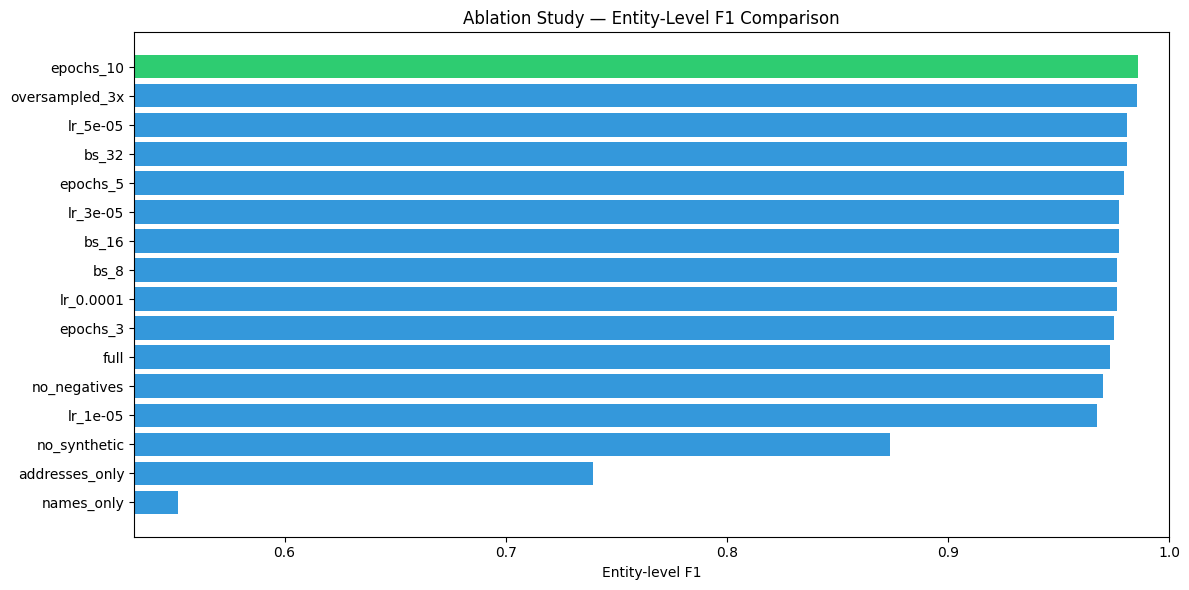

weave: 📦 Published to https://wandb.ai/ricardo-morales-b/mobile-rag-firewall/weave/objects/phi-ner-ablation-results/versions/qKckiXnYEM7uLLePEigY0iU8JLEK7Z6IHwcQgl8EA8Q


Published ablation results to Weave.


In [8]:
# Sort and display
all_results.sort(key=lambda x: -x["f1"])
print(f"\n{'='*60}\n  ABLATION RESULTS (sorted by F1)\n{'='*60}")
print(f"  {'Experiment':<25} {'F1':>10}")
print(f"  {'-'*25} {'-'*10}")
for r in all_results:
    marker = " ←best" if r == all_results[0] else ""
    print(f"  {r['name']:<25} {r['f1']:>10.4f}{marker}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
names = [r["name"] for r in all_results]
f1s = [r["f1"] for r in all_results]
colors = ["#2ecc71" if f == max(f1s) else "#3498db" for f in f1s]
ax.barh(names[::-1], f1s[::-1], color=colors[::-1])
ax.set_xlabel("Entity-level F1")
ax.set_title("Ablation Study — Entity-Level F1 Comparison")
ax.set_xlim(min(f1s) - 0.02, 1.0)
plt.tight_layout()
plt.show()

# Publish to Weave
weave.publish(all_results, name="phi-ner-ablation-results")
print("Published ablation results to Weave.")